# 06 - Model Evaluation and Decision Support

## From Prediction to Operational Decision Support

The previous notebook selected Random Forest as the main model for predicting high demand one hour ahead.

This notebook evaluates how the model could support operational decisions by examining different warning horizons, performance across system groups, missed events, operational risk levels and scenario-based energy and cost impact.

The analysis uses the same chronological evaluation framework established in the previous notebooks.

## 1. Load Data and Final 1-Hour Model

The final 1-hour Random Forest from the previous notebook is used as the primary model.

I also load the cleaned energy dataset because the 2-hour and 3-hour warning experiments require rebuilding horizon-specific targets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

df = pd.read_csv(
    "../data_processed/manufacturing_energy_clean.csv"
)

df["window_start_utc"] = pd.to_datetime(
    df["window_start_utc"]
)

df = df.sort_values(
    ["AssetId", "window_start_utc"]
).reset_index(drop=True)

print("Clean energy data:", df.shape)

Clean energy data: (1016182, 16)


### Prepare the High-Demand Definition

High demand is defined separately for each asset using its 90th percentile demand threshold.

As in the feature-engineering stage, thresholds are calculated using historical training data only.

In [2]:
split_time = pd.Timestamp("2025-11-08 20:15:00")

threshold_data = df[
    df["window_start_utc"] < split_time
].copy()

thresholds = (
    threshold_data
    .groupby("AssetId")["Demand_kW"]
    .quantile(0.90)
)

df["extreme_threshold"] = df["AssetId"].map(thresholds)

df = df[
    df["extreme_threshold"].notna()
].copy()

df["is_extreme_now"] = (
    df["Demand_kW"] > df["extreme_threshold"]
).astype(int)

print("Assets included:", df["AssetId"].nunique())
print("Missing thresholds:", df["extreme_threshold"].isna().sum())

Assets included: 37
Missing thresholds: 0


### Load the Final 1-Hour Model

The official machine-learning dataset and saved Random Forest from Notebook 5 are loaded so that the same validated 1-hour model is used throughout this notebook.

In [3]:
model_1h = pd.read_csv(
    "../data_processed/ml_ready_energy_data.csv",
    parse_dates=["window_start_utc"]
)

model_1h = model_1h.sort_values(
    "window_start_utc"
).reset_index(drop=True)

train_end_1h = split_time - pd.Timedelta(hours=1)

train_1h = model_1h[
    model_1h["window_start_utc"] < train_end_1h
].copy()

test_1h = model_1h[
    model_1h["window_start_utc"] >= split_time
].copy()

print("Training rows:", len(train_1h))
print("Test rows:", len(test_1h))

Training rows: 807338
Test rows: 185929


In [4]:
numeric_features = [
    "Demand_kW",
    "demand_15m_ago",
    "demand_30m_ago",
    "demand_45m_ago",
    "demand_60m_ago",
    "change_15m",
    "change_60m",
    "rolling_mean_1h",
    "rolling_std_1h",
    "demand_threshold_ratio",
    "hour",
    "day_of_week",
    "is_weekend"
]

categorical_features = [
    "asset_type"
]

features = numeric_features + categorical_features

X_train_1h = train_1h[features]
X_test_1h = test_1h[features]

y_train_1h = train_1h["extreme_1h_ahead"]
y_test_1h = test_1h["extreme_1h_ahead"]

In [5]:
rf_pipeline_1h = joblib.load(
    "../data_processed/rf_model_1h.joblib"
)

y_pred_1h = rf_pipeline_1h.predict(X_test_1h)
y_prob_1h = rf_pipeline_1h.predict_proba(X_test_1h)[:, 1]

print("Final 1-hour Random Forest loaded.")

Final 1-hour Random Forest loaded.


In [6]:
print(
    "ROC-AUC:",
    round(roc_auc_score(y_test_1h, y_prob_1h), 3)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_test_1h, y_prob_1h), 3)
)

ROC-AUC: 0.964
PR-AUC: 0.811


In [7]:
results_1h = test_1h[
    [
        "AssetId",
        "asset_type",
        "window_start_utc",
        "Demand_kW",
        "demand_threshold_ratio",
        "change_15m",
        "change_60m",
        "rolling_std_1h",
        "extreme_1h_ahead"
    ]
].copy()

results_1h["is_extreme_now"] = (
    results_1h["demand_threshold_ratio"] > 1
).astype(int)

results_1h["rf_pred"] = y_pred_1h
results_1h["rf_prob"] = y_prob_1h

results_1h = results_1h.sort_values(
    ["AssetId", "window_start_utc"]
).copy()

results_1h["previous_future_state"] = (
    results_1h.groupby("AssetId")["extreme_1h_ahead"]
    .shift(1)
)

results_1h["previous_time"] = (
    results_1h.groupby("AssetId")["window_start_utc"]
    .shift(1)
)

results_1h["previous_gap"] = (
    results_1h["window_start_utc"] -
    results_1h["previous_time"]
)

results_1h["validated_new_episode"] = (
    (results_1h["extreme_1h_ahead"] == 1) &
    (results_1h["previous_future_state"] == 0) &
    (results_1h["previous_gap"] == pd.Timedelta(minutes=15))
)

new_events_1h = results_1h[
    results_1h["validated_new_episode"]
].copy()

new_events_1h["baseline_pred"] = (
    new_events_1h["is_extreme_now"]
).astype(int)

print(
    "Validated new high-demand episodes:",
    len(new_events_1h)
)

Validated new high-demand episodes: 5093


In [8]:
rf_recall_1h = new_events_1h["rf_pred"].mean() * 100
baseline_recall_1h = new_events_1h["baseline_pred"].mean() * 100

print("RF recall:", round(rf_recall_1h, 2), "%")
print("Baseline recall:", round(baseline_recall_1h, 2), "%")

RF recall: 82.82 %
Baseline recall: 51.29 %


## 2. How Far Ahead Can the Model Warn?

The primary model provides a one-hour warning.

I extend the same modeling framework to two-hour and three-hour prediction horizons to examine whether useful early-warning performance can be maintained when operators are given more time to react.

In [9]:
# 2 hours = 8 × 15-minute intervals

df["future_time_2h"] = (
    df.groupby("AssetId")["window_start_utc"]
    .shift(-8)
)

df["future_extreme_2h"] = (
    df.groupby("AssetId")["is_extreme_now"]
    .shift(-8)
)

df["future_gap_2h"] = (
    df["future_time_2h"] -
    df["window_start_utc"]
)

df_2h = df[
    df["future_gap_2h"] == pd.Timedelta(hours=2)
].copy()

df_2h["extreme_2h_ahead"] = (
    df_2h["future_extreme_2h"].astype(int)
)

print("Valid 2-hour rows:", len(df_2h))

Valid 2-hour rows: 993411


In [10]:
df_2h["demand_15m_ago"] = (
    df_2h.groupby("AssetId")["Demand_kW"].shift(1)
)

df_2h["demand_30m_ago"] = (
    df_2h.groupby("AssetId")["Demand_kW"].shift(2)
)

df_2h["demand_45m_ago"] = (
    df_2h.groupby("AssetId")["Demand_kW"].shift(3)
)

df_2h["demand_60m_ago"] = (
    df_2h.groupby("AssetId")["Demand_kW"].shift(4)
)

df_2h["historical_time_1h"] = (
    df_2h.groupby("AssetId")["window_start_utc"]
    .shift(4)
)

df_2h["historical_gap_1h"] = (
    df_2h["window_start_utc"] -
    df_2h["historical_time_1h"]
)

model_2h = df_2h[
    df_2h["historical_gap_1h"] == pd.Timedelta(hours=1)
].copy()

print("Rows after validating history:", len(model_2h))

Rows after validating history: 990626


In [11]:
model_2h["change_15m"] = (
    model_2h["Demand_kW"] -
    model_2h["demand_15m_ago"]
)

model_2h["change_60m"] = (
    model_2h["Demand_kW"] -
    model_2h["demand_60m_ago"]
)

model_2h["rolling_mean_1h"] = model_2h[
    [
        "Demand_kW",
        "demand_15m_ago",
        "demand_30m_ago",
        "demand_45m_ago"
    ]
].mean(axis=1)

model_2h["rolling_std_1h"] = model_2h[
    [
        "Demand_kW",
        "demand_15m_ago",
        "demand_30m_ago",
        "demand_45m_ago"
    ]
].std(axis=1)

In [12]:
model_2h["demand_threshold_ratio"] = np.where(
    model_2h["extreme_threshold"] > 0,
    model_2h["Demand_kW"] /
    model_2h["extreme_threshold"],
    0
)

model_2h["DateLocal"] = pd.to_datetime(
    model_2h["DateLocal"]
)

model_2h["hour"] = model_2h["HourLocal"]

model_2h["day_of_week"] = (
    model_2h["DateLocal"].dt.dayofweek
)

model_2h["is_weekend"] = (
    model_2h["day_of_week"] >= 5
).astype(int)

print("2-hour modeling shape:", model_2h.shape)

2-hour modeling shape: (990626, 36)


In [13]:
model_2h = model_2h.sort_values(
    "window_start_utc"
).reset_index(drop=True)

split_time_2h = split_time

train_end_2h = (
    split_time_2h -
    pd.Timedelta(hours=2)
)

train_2h = model_2h[
    model_2h["window_start_utc"] < train_end_2h
].copy()

test_2h = model_2h[
    model_2h["window_start_utc"] >= split_time_2h
].copy()

print("Train rows:", len(train_2h))
print("Test rows:", len(test_2h))

Train rows: 804697
Test rows: 185641


In [14]:
X_train_2h = train_2h[features]
X_test_2h = test_2h[features]

y_train_2h = train_2h["extreme_2h_ahead"]
y_test_2h = test_2h["extreme_2h_ahead"]

print("X_train:", X_train_2h.shape)
print("X_test:", X_test_2h.shape)

X_train: (804697, 14)
X_test: (185641, 14)


In [15]:
preprocessor_2h = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

rf_pipeline_2h = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_2h
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline_2h.fit(
    X_train_2h,
    y_train_2h
)

y_pred_2h = rf_pipeline_2h.predict(
    X_test_2h
)

y_prob_2h = rf_pipeline_2h.predict_proba(
    X_test_2h
)[:, 1]

print("2-hour Random Forest trained.")

2-hour Random Forest trained.


In [16]:
results_2h = test_2h[
    [
        "AssetId",
        "window_start_utc",
        "is_extreme_now",
        "extreme_2h_ahead"
    ]
].copy()

results_2h["rf_pred_2h"] = y_pred_2h

results_2h = results_2h.sort_values(
    ["AssetId", "window_start_utc"]
).copy()

results_2h["previous_future_state"] = (
    results_2h
    .groupby("AssetId")["extreme_2h_ahead"]
    .shift(1)
)

results_2h["previous_time"] = (
    results_2h
    .groupby("AssetId")["window_start_utc"]
    .shift(1)
)

results_2h["previous_gap"] = (
    results_2h["window_start_utc"] -
    results_2h["previous_time"]
)

results_2h["validated_new_episode"] = (
    (results_2h["extreme_2h_ahead"] == 1) &
    (results_2h["previous_future_state"] == 0) &
    (
        results_2h["previous_gap"] ==
        pd.Timedelta(minutes=15)
    )
)

validated_events_2h = results_2h[
    results_2h["validated_new_episode"]
].copy()

print(
    "Validated new high-demand episodes:",
    len(validated_events_2h)
)

Validated new high-demand episodes: 5088


In [17]:
validated_events_2h["baseline_pred"] = (
    validated_events_2h["is_extreme_now"]
).astype(int)

rf_recall_2h = (
    validated_events_2h["rf_pred_2h"].mean()
    * 100
)

baseline_recall_2h = (
    validated_events_2h["baseline_pred"].mean()
    * 100
)

print(
    "RF 2-hour recall:",
    round(rf_recall_2h, 2),
    "%"
)

print(
    "Baseline 2-hour recall:",
    round(baseline_recall_2h, 2),
    "%"
)

RF 2-hour recall: 80.4 %
Baseline 2-hour recall: 45.66 %


### 3-Hour Early Warning

The same framework is extended to three hours to test whether useful early-warning performance can be maintained at a longer prediction horizon.

In [18]:
# 3 hours = 12 × 15-minute intervals

df["future_time_3h"] = (
    df.groupby("AssetId")["window_start_utc"]
    .shift(-12)
)

df["future_extreme_3h"] = (
    df.groupby("AssetId")["is_extreme_now"]
    .shift(-12)
)

df["future_gap_3h"] = (
    df["future_time_3h"] -
    df["window_start_utc"]
)

df_3h = df[
    df["future_gap_3h"] == pd.Timedelta(hours=3)
].copy()

df_3h["extreme_3h_ahead"] = (
    df_3h["future_extreme_3h"].astype(int)
)

print("Valid 3-hour rows:", len(df_3h))

Valid 3-hour rows: 990626


In [19]:
df_3h["demand_15m_ago"] = (
    df_3h.groupby("AssetId")["Demand_kW"]
    .shift(1)
)

df_3h["demand_30m_ago"] = (
    df_3h.groupby("AssetId")["Demand_kW"]
    .shift(2)
)

df_3h["demand_45m_ago"] = (
    df_3h.groupby("AssetId")["Demand_kW"]
    .shift(3)
)

df_3h["demand_60m_ago"] = (
    df_3h.groupby("AssetId")["Demand_kW"]
    .shift(4)
)

df_3h["historical_time_1h"] = (
    df_3h.groupby("AssetId")["window_start_utc"]
    .shift(4)
)

df_3h["historical_gap_1h"] = (
    df_3h["window_start_utc"] -
    df_3h["historical_time_1h"]
)

model_3h = df_3h[
    df_3h["historical_gap_1h"] == pd.Timedelta(hours=1)
].copy()

print(
    "Rows after validating history:",
    len(model_3h)
)

Rows after validating history: 987890


In [20]:
model_3h["change_15m"] = (
    model_3h["Demand_kW"] -
    model_3h["demand_15m_ago"]
)

model_3h["change_60m"] = (
    model_3h["Demand_kW"] -
    model_3h["demand_60m_ago"]
)

model_3h["rolling_mean_1h"] = model_3h[
    [
        "Demand_kW",
        "demand_15m_ago",
        "demand_30m_ago",
        "demand_45m_ago"
    ]
].mean(axis=1)

model_3h["rolling_std_1h"] = model_3h[
    [
        "Demand_kW",
        "demand_15m_ago",
        "demand_30m_ago",
        "demand_45m_ago"
    ]
].std(axis=1)

model_3h["demand_threshold_ratio"] = np.where(
    model_3h["extreme_threshold"] > 0,
    model_3h["Demand_kW"] /
    model_3h["extreme_threshold"],
    0
)

model_3h["DateLocal"] = pd.to_datetime(
    model_3h["DateLocal"]
)

model_3h["hour"] = model_3h["HourLocal"]

model_3h["day_of_week"] = (
    model_3h["DateLocal"].dt.dayofweek
)

model_3h["is_weekend"] = (
    model_3h["day_of_week"] >= 5
).astype(int)

print("3-hour modeling shape:", model_3h.shape)

3-hour modeling shape: (987890, 39)


In [21]:
model_3h = model_3h.sort_values(
    "window_start_utc"
).reset_index(drop=True)

split_time_3h = split_time

train_end_3h = (
    split_time_3h -
    pd.Timedelta(hours=3)
)

train_3h = model_3h[
    model_3h["window_start_utc"] < train_end_3h
].copy()

test_3h = model_3h[
    model_3h["window_start_utc"] >= split_time_3h
].copy()

print("Train rows:", len(train_3h))
print("Test rows:", len(test_3h))

Train rows: 802101
Test rows: 185357


In [22]:
X_train_3h = train_3h[features]
X_test_3h = test_3h[features]

y_train_3h = train_3h["extreme_3h_ahead"]
y_test_3h = test_3h["extreme_3h_ahead"]

print("X_train:", X_train_3h.shape)
print("X_test:", X_test_3h.shape)

X_train: (802101, 14)
X_test: (185357, 14)


In [23]:
preprocessor_3h = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

rf_pipeline_3h = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_3h
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline_3h.fit(
    X_train_3h,
    y_train_3h
)

y_pred_3h = rf_pipeline_3h.predict(
    X_test_3h
)

y_prob_3h = rf_pipeline_3h.predict_proba(
    X_test_3h
)[:, 1]

print("3-hour Random Forest trained.")

3-hour Random Forest trained.


In [24]:
results_3h = test_3h[
    [
        "AssetId",
        "window_start_utc",
        "is_extreme_now",
        "extreme_3h_ahead"
    ]
].copy()

results_3h["rf_pred_3h"] = y_pred_3h

results_3h = results_3h.sort_values(
    ["AssetId", "window_start_utc"]
).copy()

results_3h["previous_future_state"] = (
    results_3h
    .groupby("AssetId")["extreme_3h_ahead"]
    .shift(1)
)

results_3h["previous_time"] = (
    results_3h
    .groupby("AssetId")["window_start_utc"]
    .shift(1)
)

results_3h["previous_gap"] = (
    results_3h["window_start_utc"] -
    results_3h["previous_time"]
)

results_3h["validated_new_episode"] = (
    (results_3h["extreme_3h_ahead"] == 1) &
    (results_3h["previous_future_state"] == 0) &
    (
        results_3h["previous_gap"] ==
        pd.Timedelta(minutes=15)
    )
)

validated_events_3h = results_3h[
    results_3h["validated_new_episode"]
].copy()

print(
    "Validated new high-demand episodes:",
    len(validated_events_3h)
)

Validated new high-demand episodes: 5086


In [25]:
validated_events_3h["baseline_pred"] = (
    validated_events_3h["is_extreme_now"]
).astype(int)

rf_recall_3h = (
    validated_events_3h["rf_pred_3h"].mean()
    * 100
)

baseline_recall_3h = (
    validated_events_3h["baseline_pred"].mean()
    * 100
)

print(
    "RF 3-hour recall:",
    round(rf_recall_3h, 2),
    "%"
)

print(
    "Baseline 3-hour recall:",
    round(baseline_recall_3h, 2),
    "%"
)

RF 3-hour recall: 80.81 %
Baseline 3-hour recall: 42.67 %


### Warning-Horizon Comparison

The results are compared across the three prediction horizons to examine how early-warning performance changes when more reaction time is provided.

The comparison uses validated new high-demand episodes for all three horizons.

In [26]:
horizon_comparison = pd.DataFrame({
    "Warning_Horizon": [
        "1 hour",
        "2 hours",
        "3 hours"
    ],
    "Threshold_Recall": [
        baseline_recall_1h,
        baseline_recall_2h,
        baseline_recall_3h
    ],
    "ML_Recall": [
        rf_recall_1h,
        rf_recall_2h,
        rf_recall_3h
    ]
})

horizon_comparison["ML_Improvement_pp"] = (
    horizon_comparison["ML_Recall"] -
    horizon_comparison["Threshold_Recall"]
)

horizon_comparison.round(2)

,Warning_Horizon,Threshold_Recall,ML_Recall,ML_Improvement_pp
0,1 hour,51.29,82.82,31.53
1,2 hours,45.66,80.40,34.75
2,3 hours,42.67,80.81,38.14


### Key Finding: Useful Warning Is Maintained Across Longer Horizons

The Random Forest maintains around 80% recall across the tested 1-hour, 2-hour and 3-hour warning horizons, while the threshold baseline becomes less effective as the warning horizon increases.

The 1-hour model achieves the highest Random Forest recall, while the improvement over the threshold baseline becomes larger at longer warning horizons.

## 3. For Which System Groups Does Machine Learning Provide the Most Value?

The overall results show that machine learning improves early detection of high-demand events.

However, this improvement may not be equally valuable across all types of systems.

This section compares model performance across broader operational system groups to identify where machine learning provides the greatest improvement over a simple threshold-based warning.

### Simplifying Technical System Types

The original equipment categories are quite technical, so they are grouped into broader operational system groups that are easier to interpret.

This makes it easier to compare where machine learning provides the greatest improvement over a simple threshold warning.

In [27]:
def simplify_system_group(asset_type):

    if asset_type.startswith("Press") or asset_type == "ProcessMixing":
        return "Production Systems"

    elif asset_type.startswith("Automation"):
        return "Automation Systems"

    elif asset_type.startswith("HVAC"):
        return "Building & Climate Systems"

    elif (
        asset_type.startswith("Electrical")
        or asset_type == "Utilities"
        or asset_type == "CompressedAir"
    ):
        return "Electrical & Utility Systems"

    else:
        return "Other Systems"

In [28]:
system_events = new_events_1h.copy()

system_events["system_group"] = (
    system_events["asset_type"]
    .apply(simplify_system_group)
)

print(
    system_events["system_group"]
    .value_counts()
)

system_group
Production Systems              2219
Electrical & Utility Systems    1955
Building & Climate Systems       875
Automation Systems                44
Name: count, dtype: int64


In [29]:
system_group_performance = (
    system_events
    .groupby("system_group")
    .agg(
        New_Events=("validated_new_episode", "count"),
        ML_Detected=("rf_pred", "sum"),
        Threshold_Detected=("baseline_pred", "sum")
    )
    .reset_index()
)

system_group_performance["ML_Recall_Pct"] = (
    system_group_performance["ML_Detected"] /
    system_group_performance["New_Events"] * 100
)

system_group_performance["Threshold_Recall_Pct"] = (
    system_group_performance["Threshold_Detected"] /
    system_group_performance["New_Events"] * 100
)

system_group_performance["ML_Improvement_pp"] = (
    system_group_performance["ML_Recall_Pct"] -
    system_group_performance["Threshold_Recall_Pct"]
)

system_group_performance = (
    system_group_performance
    .sort_values("ML_Improvement_pp", ascending=False)
)

system_group_performance.round(2)

,system_group,New_Events,ML_Detected,Threshold_Detected,ML_Recall_Pct,Threshold_Recall_Pct,ML_Improvement_pp
0,Automation Systems,44,42,19,95.45,43.18,52.27
1,Building & Climate Systems,875,773,430,88.34,49.14,39.20
3,Production Systems,2219,1722,1055,77.60,47.54,30.06
2,Electrical & Utility Systems,1955,1681,1108,85.98,56.68,29.31


### Key Finding: ML Value Depends on the System

Machine-learning performance varies across operational system groups.

The Random Forest improves early-warning recall compared with the threshold baseline across the main system groups. The largest improvement appears in Automation Systems, although this group contains relatively few validated events and should therefore be interpreted cautiously.

## 4. What Types of High-Demand Events Does the Model Miss?

Even a strong early-warning model cannot detect every new high-demand event.

This section compares successfully detected and missed new high-demand episodes to understand whether missed events show weaker warning signals before they occur.

In [30]:
event_analysis = new_events_1h.copy()

event_analysis["Detection_Result"] = np.where(
    event_analysis["rf_pred"] == 1,
    "Detected by ML",
    "Missed by ML"
)

print(
    event_analysis["Detection_Result"]
    .value_counts()
)

print("\nPercentages:")

print(
    event_analysis["Detection_Result"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Detection_Result
Detected by ML    4218
Missed by ML       875
Name: count, dtype: int64

Percentages:
Detection_Result
Detected by ML    82.82
Missed by ML      17.18
Name: proportion, dtype: float64


In [31]:
failure_median_comparison = (
    event_analysis
    .groupby("Detection_Result")
    .agg(
        Events=("validated_new_episode", "count"),
        Median_Current_Demand=("Demand_kW", "median"),
        Median_15m_Change=("change_15m", "median"),
        Median_60m_Change=("change_60m", "median"),
        Median_Threshold_Ratio=("demand_threshold_ratio", "median"),
        Median_Rolling_Std=("rolling_std_1h", "median")
    )
    .round(2)
)

failure_median_comparison

,Events,Median_Current_Demand,Median_15m_Change,Median_60m_Change,Median_Threshold_Ratio,Median_Rolling_Std
Detection_Result,,,,,,
Detected by ML,4218,5.90,0.0,0.01,1.05,0.75
Missed by ML,875,3.32,-0.0,-0.00,0.54,0.24


### Key Finding: Missed Events Show Weaker Early Warning Signals

Missed high-demand episodes tend to show weaker warning signals before the event begins.

Compared with detected events, they are typically farther below the high-demand threshold and show less recent variability. This suggests that some events are more difficult to predict from historical electricity-demand patterns alone.

Additional operational information, such as production schedules or machine states, could potentially help identify these more difficult events.

## 5. Turning Predictions into Operational Risk Levels

To make the early-warning model more useful for decision support, Random Forest probabilities are translated into four operational risk levels.

These risk levels provide a simple way to prioritize attention based on the predicted probability of high demand.

In [32]:
probability_summary = pd.DataFrame({
    "Predicted_Probability": y_prob_1h,
    "Actual_High_Demand": y_test_1h.values
})

print(
    probability_summary["Predicted_Probability"]
    .describe()
    .round(3)
)

print("\nMedian probability by actual outcome:")

print(
    probability_summary
    .groupby("Actual_High_Demand")["Predicted_Probability"]
    .median()
    .round(3)
)

count    185929.000
mean          0.268
std           0.315
min           0.001
25%           0.035
50%           0.111
75%           0.416
max           0.998
Name: Predicted_Probability, dtype: float64

Median probability by actual outcome:
Actual_High_Demand
0    0.082
1    0.874
Name: Predicted_Probability, dtype: float64


In [33]:
results_1h["risk_level"] = pd.cut(
    results_1h["rf_prob"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.00],
    labels=[
        "Low",
        "Elevated",
        "High",
        "Critical"
    ]
)

risk_summary = (
    results_1h
    .groupby("risk_level", observed=True)
    .agg(
        Predictions=("rf_prob", "count"),
        Actual_High_Demand=("extreme_1h_ahead", "sum"),
        Avg_Model_Score=("rf_prob", "mean")
    )
    .reset_index()
)

risk_summary["Actual_High_Demand_Rate_Pct"] = (
    risk_summary["Actual_High_Demand"] /
    risk_summary["Predictions"] * 100
)

risk_summary.round(2)

,risk_level,Predictions,Actual_High_Demand,Avg_Model_Score,Actual_High_Demand_Rate_Pct
0,Low,125952,719,0.08,0.57
1,Elevated,17894,1327,0.35,7.42
2,High,12561,4518,0.63,35.97
3,Critical,29522,22651,0.88,76.73


### Key Finding: Model Probabilities Can Support Risk Prioritization

The Random Forest probabilities are grouped into four simple operational risk levels: Low, Elevated, High and Critical.

The observed high-demand rate increases across these risk levels, showing that higher model probabilities correspond to greater high-demand risk.

These bands are used as simple interpretation levels for decision support rather than optimized intervention thresholds.

## 6. What Could Early Warning Mean for Energy and Potential Cost Impact?

The model can identify high-demand episodes before they begin, but the dataset does not show what would happen after an operational intervention.

Therefore, this section uses simple scenarios to estimate the potential energy and cost impact if a proportion of energy use during successfully warned episodes could be reduced.

In [34]:
# Successfully detected validated new events
detected_starts = event_analysis[
    event_analysis["rf_pred"] == 1
].copy()

# The event actually begins one hour after the prediction
detected_starts["actual_event_start"] = (
    detected_starts["window_start_utc"] +
    pd.Timedelta(hours=1)
)

print("Successfully warned event starts:", len(detected_starts))

print(
    detected_starts[
        ["AssetId", "window_start_utc", "actual_event_start"]
    ].head()
)

Successfully warned event starts: 4218
       AssetId    window_start_utc  actual_event_start
812930   ahu_b 2025-11-10 10:00:00 2025-11-10 11:00:00
813411   ahu_b 2025-11-10 13:30:00 2025-11-10 14:30:00
813530   ahu_b 2025-11-10 14:15:00 2025-11-10 15:15:00
814014   ahu_b 2025-11-10 17:45:00 2025-11-10 18:45:00
814450   ahu_b 2025-11-10 20:30:00 2025-11-10 21:30:00


In [35]:
# Actual high-demand observations from the original data
actual_energy = df[
    [
        "AssetId",
        "window_start_utc",
        "Energy_kWh_15m",
        "Demand_kW",
        "is_extreme_now"
    ]
].copy()

actual_energy = actual_energy.sort_values(
    ["AssetId", "window_start_utc"]
)

# Previous actual state and timestamp
actual_energy["previous_extreme"] = (
    actual_energy.groupby("AssetId")["is_extreme_now"]
    .shift(1)
)

actual_energy["previous_time"] = (
    actual_energy.groupby("AssetId")["window_start_utc"]
    .shift(1)
)

actual_energy["time_gap"] = (
    actual_energy["window_start_utc"] -
    actual_energy["previous_time"]
)

# Identify actual episode starts
actual_energy["episode_start"] = (
    (actual_energy["is_extreme_now"] == 1) &
    (
        (actual_energy["previous_extreme"] != 1) |
        (actual_energy["time_gap"] != pd.Timedelta(minutes=15))
    )
)

# Episode IDs
actual_energy["episode_id"] = (
    actual_energy.groupby("AssetId")["episode_start"]
    .cumsum()
)

# Keep actual high-demand observations
actual_high = actual_energy[
    actual_energy["is_extreme_now"] == 1
].copy()

# Summarize each actual episode
actual_episode_summary = (
    actual_high
    .groupby(["AssetId", "episode_id"])
    .agg(
        Actual_Event_Start=("window_start_utc", "min"),
        Intervals=("window_start_utc", "size"),
        Episode_Energy_kWh=("Energy_kWh_15m", "sum")
    )
    .reset_index()
)

actual_episode_summary["Duration_Minutes"] = (
    actual_episode_summary["Intervals"] * 15
)

print("Actual high-demand episodes:", len(actual_episode_summary))

Actual high-demand episodes: 27030


In [36]:
warned_episode_summary = detected_starts.merge(
    actual_episode_summary,
    left_on=["AssetId", "actual_event_start"],
    right_on=["AssetId", "Actual_Event_Start"],
    how="inner"
)

print(
    "Successfully warned episodes matched:",
    len(warned_episode_summary)
)

print(
    "Total energy during matched episodes:",
    round(
        warned_episode_summary["Episode_Energy_kWh"].sum(),
        2
    ),
    "kWh"
)

print(
    "Median warned episode duration:",
    warned_episode_summary["Duration_Minutes"].median(),
    "minutes"
)

print(
    "Median warned episode energy:",
    round(
        warned_episode_summary["Episode_Energy_kWh"].median(),
        2
    ),
    "kWh"
)

Successfully warned episodes matched: 4218
Total energy during matched episodes: 168134.25 kWh
Median warned episode duration: 30.0 minutes
Median warned episode energy: 4.07 kWh


### Scenario-Based Impact Estimate

Because the dataset does not contain actual intervention outcomes or the facility's electricity tariff, the following calculations are hypothetical scenarios rather than measured savings.

The analysis considers possible energy reductions of 5%, 10% and 20% during successfully warned high-demand episodes, together with illustrative electricity prices.

In [37]:
episode_energy_reference = (
    warned_episode_summary["Episode_Energy_kWh"].sum()
)

reduction_rates = [0.05, 0.10, 0.20]
electricity_prices = [0.10, 0.20, 0.30, 0.40]

final_impact_scenarios = []

for reduction in reduction_rates:
    
    potential_energy_reduction = (
        episode_energy_reference * reduction
    )
    
    for price in electricity_prices:
        
        potential_cost_impact = (
            potential_energy_reduction * price
        )
        
        final_impact_scenarios.append({
            "Intervention_Effectiveness_Pct": reduction * 100,
            "Electricity_Price_EUR_per_kWh": price,
            "Potential_Energy_Reduction_kWh":
                potential_energy_reduction,
            "Potential_Cost_Impact_EUR":
                potential_cost_impact
        })

final_impact_scenarios = pd.DataFrame(
    final_impact_scenarios
)

final_impact_scenarios.round(2)

,Intervention_Effectiveness_Pct,Electricity_Price_EUR_per_kWh,Potential_Energy_Reduction_kWh,Potential_Cost_Impact_EUR
0,5.0,0.1,8406.71,840.67
1,5.0,0.2,8406.71,1681.34
2,5.0,0.3,8406.71,2522.01
3,5.0,0.4,8406.71,3362.69
4,10.0,0.1,16813.43,1681.34
5,10.0,0.2,16813.43,3362.69
6,10.0,0.3,16813.43,5044.03
7,10.0,0.4,16813.43,6725.37
8,20.0,0.1,33626.85,3362.69
9,20.0,0.2,33626.85,6725.37


In [38]:
# =========================================================
# Export final 1-hour predictions for the dashboard
# =========================================================

dashboard_data = X_test_1h.copy()

dashboard_data["window_start_utc"] = (
    test_1h["window_start_utc"].values
)

dashboard_data["AssetId"] = (
    test_1h["AssetId"].values
)

dashboard_data["actual_high_demand"] = (
    y_test_1h.values
)

dashboard_data["predicted_high_demand"] = (
    y_pred_1h
)

dashboard_data["risk_probability"] = (
    y_prob_1h
)

dashboard_data["risk_level"] = pd.cut(
    dashboard_data["risk_probability"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.00],
    labels=["Low", "Elevated", "High", "Critical"]
)

dashboard_data = dashboard_data.sort_values(
    ["AssetId", "window_start_utc"]
)

dashboard_data["previous_high_demand"] = (
    dashboard_data
    .groupby("AssetId")["actual_high_demand"]
    .shift(1)
)

dashboard_data["episode_start"] = (
    (dashboard_data["actual_high_demand"] == 1) &
    (dashboard_data["previous_high_demand"] != 1)
).astype(int)

dashboard_data = dashboard_data.drop(
    columns=["previous_high_demand"]
)

facility_demand = (
    dashboard_data
    .groupby("window_start_utc")["Demand_kW"]
    .sum()
)

facility_threshold = (
    facility_demand.quantile(0.99)
)

facility_high = (
    facility_demand >= facility_threshold
)

recent_high = (
    facility_high
    .rolling(window=16, min_periods=1)
    .max()
    .shift(1)
    .fillna(0)
)

facility_event_start = (
    facility_high &
    (recent_high == 0)
).astype(int)

dashboard_data["facility_event_start"] = (
    dashboard_data["window_start_utc"]
    .map(facility_event_start)
    .fillna(0)
    .astype(int)
)

print(
    "Number of facility events:",
    facility_event_start.sum()
)

dashboard_data.to_csv(
    "../data_processed/energy_risk_predictions.csv",
    index=False
)

print("Dashboard dataset saved.")
print("Rows:", len(dashboard_data))

print(
    "Timestamp:",
    dashboard_data["window_start_utc"].min(),
    "to",
    dashboard_data["window_start_utc"].max()
)

print(
    dashboard_data["risk_level"]
    .value_counts()
    .sort_index()
)

Number of facility events: 18
Dashboard dataset saved.
Rows: 185929
Timestamp: 2025-11-08 20:15:00 to 2025-12-31 22:45:00
risk_level
Low         125952
Elevated     17894
High         12561
Critical     29522
Name: count, dtype: int64


In [39]:
demo_data = dashboard_data.sample(
    n=min(10000, len(dashboard_data)),
    random_state=42
)

demo_file = "../app/data/energy_risk_predictions_demo.csv"

demo_data.to_csv(demo_file, index=False)

print("Demo dashboard dataset saved.")
print("Rows:", len(demo_data))

Demo dashboard dataset saved.
Rows: 10000


## 7. Summary and Decision-Support Implications

This notebook extended the one-hour Random Forest model into a broader decision-support framework.

The main findings are:

- Random Forest maintains around 80% recall across the tested 1-hour, 2-hour and 3-hour warning horizons.
- Machine learning provides more value than the threshold baseline across the main operational system groups, although performance differs between systems.
- Missed events generally show weaker advance warning signals in recent demand behavior.
- Predicted probabilities can be translated into simple Low, Elevated, High and Critical risk levels to support prioritization.
- Successfully warned high-demand episodes can be used for scenario-based energy and cost-impact estimates, but these estimates are hypothetical rather than measured savings.

Overall, the model provides advance warning that could help operators investigate upcoming high-demand risk and decide where intervention may be most useful.

A key limitation is that the dataset contains electricity-demand history but not operational variables such as production schedules, machine states or actual intervention outcomes. These additional data sources could improve prediction of more difficult events and allow future validation of real energy and cost savings.

The next notebook focuses specifically on model errors, including false positives, false negatives and where prediction errors are concentrated.

## Presentation Visuals

### Baseline vs Random Forest — 1-Hour Early Warning

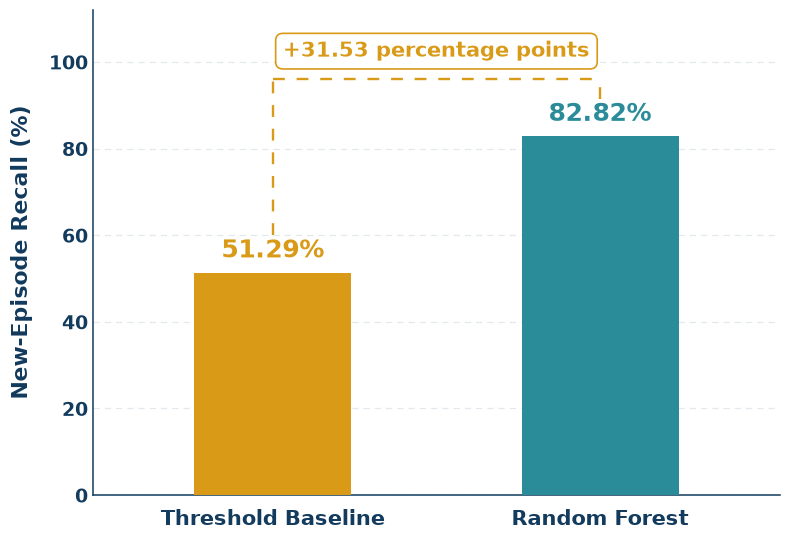

In [40]:
import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------------------------
# SLIDE 10
# New-Episode Recall — Baseline vs Random Forest
# ---------------------------------------------------------


# ---------------------------------------------------------
# Final validated episode-level results
# ---------------------------------------------------------

models = [
    "Threshold Baseline",
    "Random Forest"
]

episode_recall = [
    51.29,
    82.82
]

improvement = episode_recall[1] - episode_recall[0]


# ---------------------------------------------------------
# Presentation colors
# ---------------------------------------------------------

navy = "#123B5D"
teal = "#2B8C99"
gold = "#D99A18"
grid_grey = "#DDE5EA"


# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5))

# Transparent outside area for PowerPoint
fig.patch.set_alpha(0)

# White chart area
ax.set_facecolor("white")


# ---------------------------------------------------------
# Bar positions
# ---------------------------------------------------------

x = np.arange(len(models))


# ---------------------------------------------------------
# Bars
# ---------------------------------------------------------

bars = ax.bar(
    x,
    episode_recall,
    width=0.48,
    color=[gold, teal],
    edgecolor="none",
    zorder=3
)


# ---------------------------------------------------------
# Values above bars
# ---------------------------------------------------------

for bar, value, color in zip(
    bars,
    episode_recall,
    [gold, teal]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2.2,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        color=color,
        zorder=7
    )


# ---------------------------------------------------------
# Gold dashed comparison bracket
# No arrow
# ---------------------------------------------------------

x1 = x[0]
x2 = x[1]

bracket_y = 96

# Keep the vertical lines away from the percentage labels
left_start = 60
right_start = 91.5


# Left vertical dashed connector
ax.plot(
    [x1, x1],
    [left_start, bracket_y],
    color=gold,
    linewidth=1.7,
    linestyle=(0, (5, 5)),
    solid_capstyle="butt",
    dash_capstyle="butt",
    zorder=4
)


# Top horizontal dashed line
ax.plot(
    [x1, x2],
    [bracket_y, bracket_y],
    color=gold,
    linewidth=1.7,
    linestyle=(0, (5, 5)),
    solid_capstyle="butt",
    dash_capstyle="butt",
    zorder=4
)


# Right vertical dashed connector
# No arrow — just a clean short dashed line
ax.plot(
    [x2, x2],
    [right_start, bracket_y],
    color=gold,
    linewidth=1.7,
    linestyle=(0, (5, 5)),
    solid_capstyle="butt",
    dash_capstyle="butt",
    zorder=4
)


# ---------------------------------------------------------
# Improvement annotation
# Positioned cleanly above dashed bracket
# ---------------------------------------------------------

ax.text(
    (x1 + x2) / 2,
    102.5,
    f"+{improvement:.2f} percentage points",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
    color=gold,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor=gold,
        linewidth=1.2
    ),
    zorder=8
)


# ---------------------------------------------------------
# Y-axis
# ---------------------------------------------------------

ax.set_ylabel(
    "New-Episode Recall (%)",
    fontsize=16,
    fontweight="bold",
    color=navy,
    labelpad=12
)

ax.set_ylim(0, 112)

ax.set_yticks(
    np.arange(0, 101, 20)
)


# ---------------------------------------------------------
# X-axis
# ---------------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    models,
    fontsize=15,
    fontweight="bold",
    color=navy
)


# ---------------------------------------------------------
# Tick styling
# ---------------------------------------------------------

ax.tick_params(
    axis="y",
    labelsize=14,
    colors=navy,
    length=0
)

ax.tick_params(
    axis="x",
    labelsize=15,
    colors=navy,
    length=0,
    pad=10
)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

for label in ax.get_xticklabels():
    label.set_fontweight("bold")


# ---------------------------------------------------------
# Grid
# ---------------------------------------------------------

ax.grid(
    axis="y",
    linestyle=(0, (5, 4)),
    linewidth=0.9,
    color=grid_grey,
    alpha=0.85
)

ax.grid(
    axis="x",
    visible=False
)

ax.set_axisbelow(True)


# ---------------------------------------------------------
# Borders / spines
# ---------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(navy)
ax.spines["bottom"].set_color(navy)

ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)


# ---------------------------------------------------------
# Horizontal spacing
# ---------------------------------------------------------

ax.set_xlim(
    -0.55,
    1.55
)


# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

plt.tight_layout()


# ---------------------------------------------------------
# Save for presentation
# ---------------------------------------------------------

plt.savefig(
    "../presentation/new_episode_recall_comparison.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

### Early-Warning Performance Across Prediction Horizons

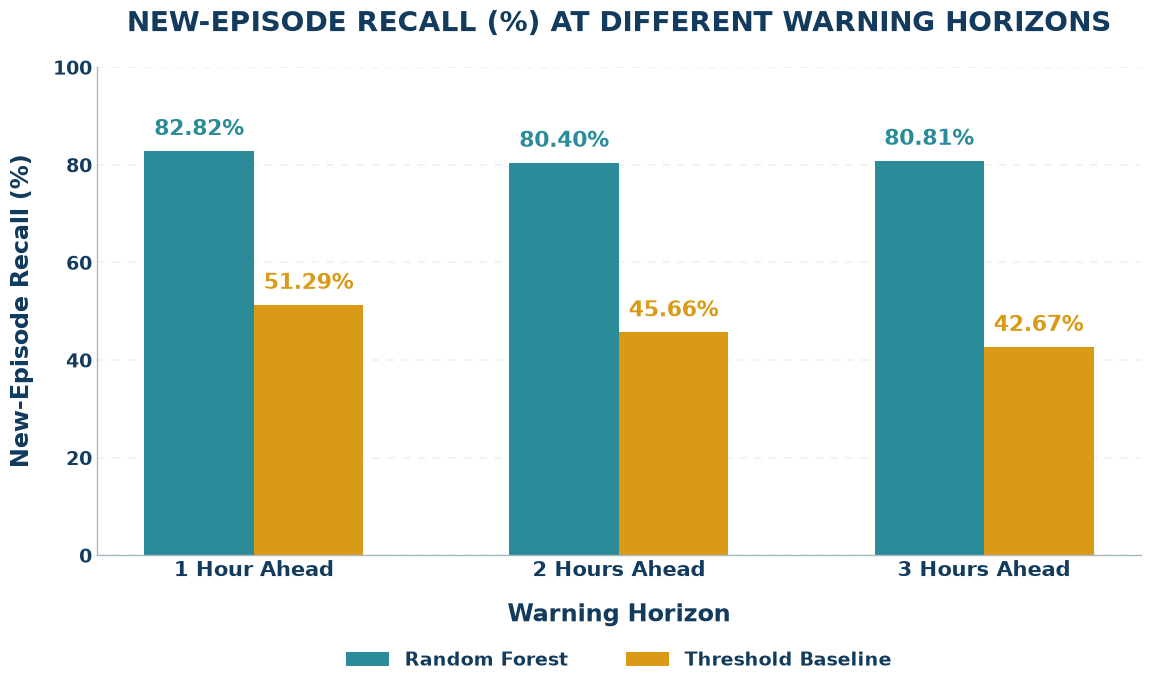

In [41]:
# =========================================================
# SLIDE 12 VISUAL:
# Warning Horizon
# Random Forest vs Threshold Baseline
# =========================================================

import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# FINAL VALIDATED EPISODE-LEVEL RESULTS
# =========================================================

horizons = ["1 Hour Ahead", "2 Hours Ahead", "3 Hours Ahead"]

rf_recall = [82.82, 80.40, 80.81]
baseline_recall = [51.29, 45.66, 42.67]


# =========================================================
# PRESENTATION COLORS
# =========================================================

navy = "#123B5D"
teal = "#2B8C99"
gold = "#D99A18"
light_grey = "#E7EEF2"
axis_grey = "#AAB8C2"


# =========================================================
# FIGURE
# =========================================================

x = np.arange(len(horizons))
width = 0.30

fig, ax = plt.subplots(
    figsize=(12, 8)
)

fig.patch.set_alpha(0)
ax.set_facecolor("white")


# =========================================================
# BARS
# =========================================================

# Random Forest — teal
bars_rf = ax.bar(
    x - width / 2,
    rf_recall,
    width,
    label="Random Forest",
    color=teal,
    edgecolor="none"
)


# Threshold Baseline — gold
bars_baseline = ax.bar(
    x + width / 2,
    baseline_recall,
    width,
    label="Threshold Baseline",
    color=gold,
    edgecolor="none"
)


# =========================================================
# VALUE LABELS
# =========================================================

for bar in bars_rf:
    value = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2.2,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold",
        color=teal
    )


for bar in bars_baseline:
    value = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2.2,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold",
        color=gold
    )


# =========================================================
# TITLE
# =========================================================

ax.set_title(
    "NEW-EPISODE RECALL (%) AT DIFFERENT WARNING HORIZONS",
    fontsize=20,
    fontweight="bold",
    color=navy,
    pad=26
)


# =========================================================
# AXIS LABELS
# =========================================================

ax.set_ylabel(
    "New-Episode Recall (%)",
    fontsize=17,
    fontweight="bold",
    color=navy,
    labelpad=14
)

ax.set_xlabel(
    "Warning Horizon",
    fontsize=17,
    fontweight="bold",
    color=navy,
    labelpad=16
)


# =========================================================
# X AXIS
# =========================================================

ax.set_xticks(x)

ax.set_xticklabels(
    horizons,
    fontsize=15,
    fontweight="bold",
    color=navy
)


# =========================================================
# Y AXIS
# =========================================================

ax.set_ylim(0, 100)

y_ticks = [0, 20, 40, 60, 80, 100]

ax.set_yticks(y_ticks)

ax.set_yticklabels(
    [str(v) for v in y_ticks],
    fontsize=14,
    fontweight="bold",
    color=navy
)

ax.tick_params(
    axis="both",
    length=0
)


# =========================================================
# LIGHT HORIZONTAL GRID
# =========================================================

ax.grid(
    axis="y",
    color=light_grey,
    linewidth=1.1,
    linestyle=(0, (5, 5)),
    alpha=0.9
)

ax.set_axisbelow(True)


# =========================================================
# LEGEND
# =========================================================

legend = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    fontsize=14,
    frameon=False,
    handlelength=2.2,
    columnspacing=3
)

for text in legend.get_texts():
    text.set_color(navy)
    text.set_fontweight("bold")


# =========================================================
# CLEAN BORDERS
# =========================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(axis_grey)
ax.spines["bottom"].set_color(axis_grey)

ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)


# =========================================================
# SPACING
# =========================================================

plt.subplots_adjust(
    left=0.10,
    right=0.97,
    bottom=0.23,
    top=0.84
)


# =========================================================
# SAVE
# =========================================================

plt.savefig(
    "../presentation/warning_horizon_light.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

### Technical Model Validation — ROC and Precision-Recall Curves

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


# ---------------------------------------------------------
# Recreate Logistic Regression in Notebook 6
# using the SAME 1-hour train/test data and features
# ---------------------------------------------------------

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)


logistic_model_1h = Pipeline(
    steps=[
        (
            "preprocessor",
            logistic_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


# Train Logistic Regression
logistic_model_1h.fit(
    X_train_1h,
    y_train_1h
)


# Probabilities on SAME test set
logistic_prob_1h = logistic_model_1h.predict_proba(
    X_test_1h
)[:, 1]


print("Logistic Regression recreated in Notebook 6.")

Logistic Regression recreated in Notebook 6.


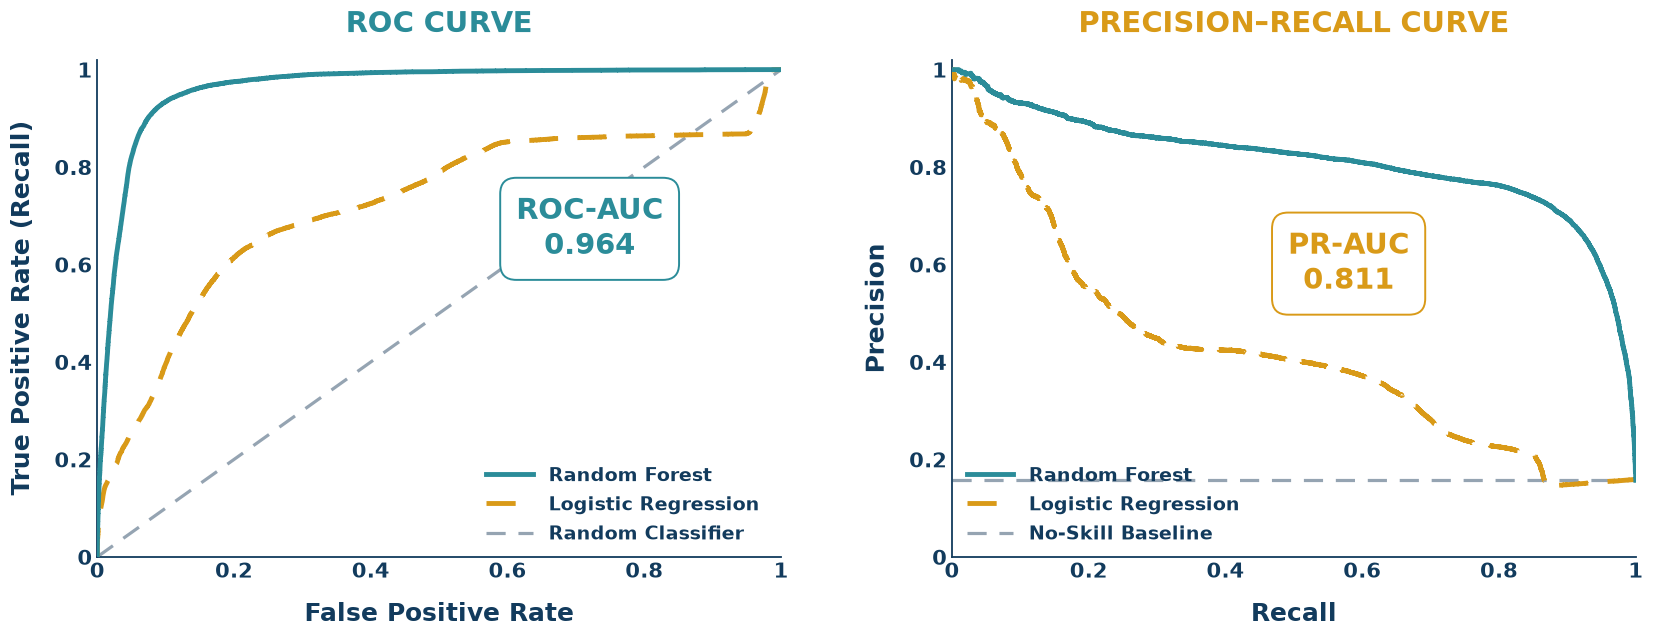

Random Forest
ROC-AUC: 0.964
PR-AUC:  0.811

Logistic Regression
ROC-AUC: 0.720
PR-AUC:  0.422

PR No-Skill Baseline
Positive-class rate: 0.157


In [43]:
# =========================================================
# PRESENTATION VISUAL:
# ROC + Precision-Recall curves
# Random Forest vs Logistic Regression
# Notebook 6
# =========================================================

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)


# =========================================================
# PRESENTATION COLORS
# =========================================================

navy = "#123B5D"
teal = "#2B8C99"
gold = "#D99A18"
grey = "#8A9AAA"


# =========================================================
# 1. RECREATE LOGISTIC REGRESSION IN NOTEBOOK 6
# =========================================================

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)


logistic_model_1h = Pipeline(
    steps=[
        (
            "preprocessor",
            logistic_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


logistic_model_1h.fit(
    X_train_1h,
    y_train_1h
)


logistic_prob_1h = logistic_model_1h.predict_proba(
    X_test_1h
)[:, 1]


# =========================================================
# 2. RANDOM FOREST CURVES
# =========================================================

rf_fpr, rf_tpr, _ = roc_curve(
    y_test_1h,
    y_prob_1h
)

rf_roc_auc = roc_auc_score(
    y_test_1h,
    y_prob_1h
)


rf_precision, rf_recall, _ = precision_recall_curve(
    y_test_1h,
    y_prob_1h
)

rf_pr_auc = average_precision_score(
    y_test_1h,
    y_prob_1h
)


# =========================================================
# 3. LOGISTIC REGRESSION CURVES
# =========================================================

lr_fpr, lr_tpr, _ = roc_curve(
    y_test_1h,
    logistic_prob_1h
)

lr_roc_auc = roc_auc_score(
    y_test_1h,
    logistic_prob_1h
)


lr_precision, lr_recall, _ = precision_recall_curve(
    y_test_1h,
    logistic_prob_1h
)

lr_pr_auc = average_precision_score(
    y_test_1h,
    logistic_prob_1h
)


# =========================================================
# 4. PRECISION-RECALL BASELINE
# =========================================================

positive_rate = y_test_1h.mean()


# =========================================================
# 5. FIGURE
# =========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 7)
)

fig.patch.set_alpha(0)


# Same ticks for both plots
ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]

tick_labels = [
    "0",
    "0.2",
    "0.4",
    "0.6",
    "0.8",
    "1"
]


# =========================================================
# ROC CURVE
# =========================================================

ax = axes[0]

ax.set_facecolor("white")


# Random Forest
ax.plot(
    rf_fpr,
    rf_tpr,
    color=teal,
    linewidth=3.5,
    label="Random Forest",
    zorder=5
)


# Logistic Regression
# BOLDER dashed line
ax.plot(
    lr_fpr,
    lr_tpr,
    color=gold,
    linewidth=3.5,
    linestyle=(0, (6, 4)),
    label="Logistic Regression",
    zorder=4
)


# Random classifier
# BOLDER dashed reference line
ax.plot(
    [0, 1],
    [0, 1],
    color=grey,
    linewidth=2.3,
    linestyle=(0, (6, 4)),
    alpha=0.9,
    label="Random Classifier",
    zorder=2
)


# Title
ax.set_title(
    "ROC CURVE",
    fontsize=21,
    fontweight="bold",
    color=teal,
    pad=20
)


# Axis labels
ax.set_xlabel(
    "False Positive Rate",
    fontsize=18,
    fontweight="bold",
    color=navy,
    labelpad=14
)

ax.set_ylabel(
    "True Positive Rate (Recall)",
    fontsize=18,
    fontweight="bold",
    color=navy,
    labelpad=14
)


# Limits
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)


# Axis numbers
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xticklabels(
    tick_labels,
    fontsize=15,
    fontweight="bold",
    color=navy
)

ax.set_yticklabels(
    tick_labels,
    fontsize=15,
    fontweight="bold",
    color=navy
)

ax.tick_params(
    axis="both",
    length=0
)


# NO GRID
ax.grid(False)


# ---------------------------------------------------------
# ROC-AUC CALLOUT
# ---------------------------------------------------------

ax.text(
    0.72,
    0.66,
    f"ROC-AUC\n{rf_roc_auc:.3f}",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=21,
    fontweight="bold",
    color=teal,
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="white",
        edgecolor=teal,
        linewidth=1.4
    ),
    zorder=7
)


# Legend
legend = ax.legend(
    loc="lower right",
    bbox_to_anchor=(0.98, 0.01),
    fontsize=14,
    frameon=False,
    handlelength=2.4,
    handletextpad=0.8,
    labelspacing=0.5,
    borderaxespad=0.0
)

for text in legend.get_texts():
    text.set_color(navy)
    text.set_fontweight("bold")


# =========================================================
# PRECISION-RECALL CURVE
# =========================================================

ax = axes[1]

ax.set_facecolor("white")


# Random Forest
ax.plot(
    rf_recall,
    rf_precision,
    color=teal,
    linewidth=3.5,
    label="Random Forest",
    zorder=5
)


# Logistic Regression
# BOLDER dashed line
ax.plot(
    lr_recall,
    lr_precision,
    color=gold,
    linewidth=3.5,
    linestyle=(0, (6, 4)),
    label="Logistic Regression",
    zorder=4
)


# No-skill baseline
# BOLDER dashed reference line
ax.axhline(
    y=positive_rate,
    color=grey,
    linewidth=2.3,
    linestyle=(0, (6, 4)),
    alpha=0.9,
    label="No-Skill Baseline",
    zorder=2
)


# Title
ax.set_title(
    "PRECISION–RECALL CURVE",
    fontsize=21,
    fontweight="bold",
    color=gold,
    pad=20
)


# Axis labels
ax.set_xlabel(
    "Recall",
    fontsize=18,
    fontweight="bold",
    color=navy,
    labelpad=14
)

ax.set_ylabel(
    "Precision",
    fontsize=18,
    fontweight="bold",
    color=navy,
    labelpad=14
)


# Limits
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)


# Axis numbers
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xticklabels(
    tick_labels,
    fontsize=15,
    fontweight="bold",
    color=navy
)

ax.set_yticklabels(
    tick_labels,
    fontsize=15,
    fontweight="bold",
    color=navy
)

ax.tick_params(
    axis="both",
    length=0
)


# NO GRID
ax.grid(False)


# ---------------------------------------------------------
# PR-AUC CALLOUT
# ---------------------------------------------------------

ax.text(
    0.58,
    0.59,
    f"PR-AUC\n{rf_pr_auc:.3f}",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=21,
    fontweight="bold",
    color=gold,
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="white",
        edgecolor=gold,
        linewidth=1.4
    ),
    zorder=7
)


# Legend
legend = ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.01, 0.01),
    fontsize=14,
    frameon=False,
    handlelength=2.4,
    handletextpad=0.8,
    labelspacing=0.5,
    borderaxespad=0.0
)

for text in legend.get_texts():
    text.set_color(navy)
    text.set_fontweight("bold")


# =========================================================
# CLEAN BORDERS
# =========================================================

for ax in axes:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color(navy)
    ax.spines["bottom"].set_color(navy)

    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)


# =========================================================
# SPACING
# =========================================================

plt.subplots_adjust(
    left=0.075,
    right=0.98,
    bottom=0.16,
    top=0.87,
    wspace=0.25
)


# =========================================================
# SAVE
# =========================================================

plt.savefig(
    "../presentation/roc_pr_final_1h_light.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()


# =========================================================
# CHECK VALUES
# =========================================================

print("Random Forest")
print(f"ROC-AUC: {rf_roc_auc:.3f}")
print(f"PR-AUC:  {rf_pr_auc:.3f}")

print("\nLogistic Regression")
print(f"ROC-AUC: {lr_roc_auc:.3f}")
print(f"PR-AUC:  {lr_pr_auc:.3f}")

print("\nPR No-Skill Baseline")
print(f"Positive-class rate: {positive_rate:.3f}")

Using dataframe: results_1h
Rows available: 185,929

REAL RISK-LEVEL MEDIANS
----------------------------------------------
Low        | n = 125,952 | median = 0.064
Elevated   | n =  17,894 | median = 0.707
High       | n =  12,561 | median = 0.945
Critical   | n =  29,522 | median = 1.228


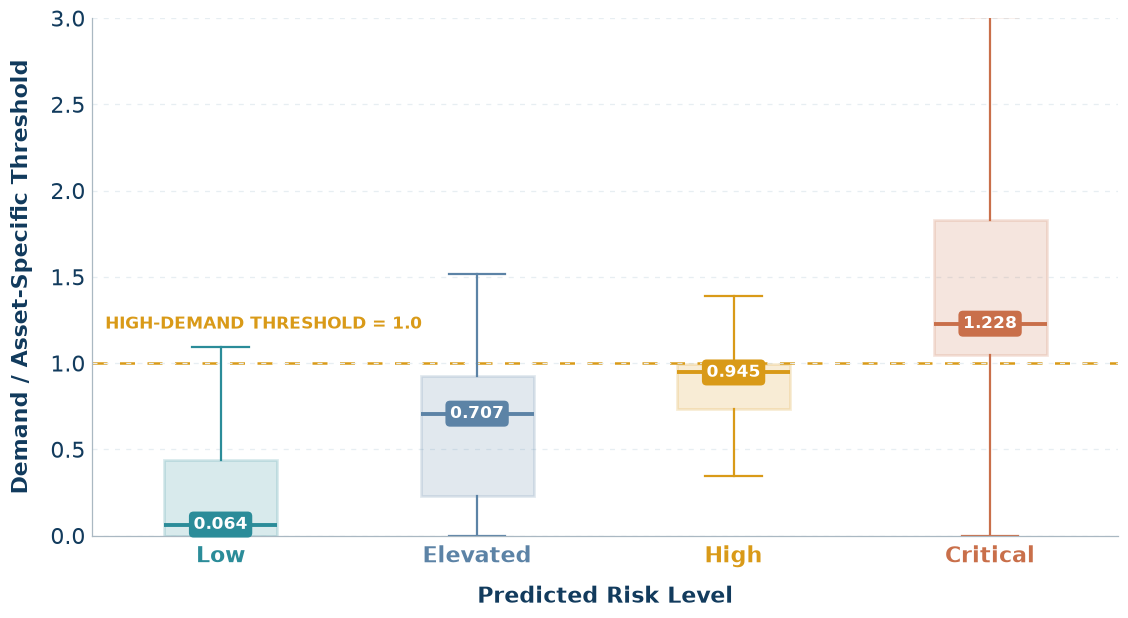

In [44]:
# =========================================================

navy = "#123B5D"
teal = "#2B8C99"
gold = "#D99A18"
light_grey = "#E7EEF2"
axis_grey = "#AAB8C2"

# Extra muted corporate colors for distinction
blue = "#5C83A6"
coral = "#C96F4A"


risk_colors = {
    "Low": teal,
    "Elevated": blue,
    "High": gold,
    "Critical": coral
}


# =========================================================
# FIND REAL DATAFRAME
# =========================================================

risk_df = None
risk_df_name = None

for name, obj in list(globals().items()):

    if not isinstance(obj, pd.DataFrame):
        continue

    required = {
        "risk_level",
        "demand_threshold_ratio"
    }

    if required.issubset(obj.columns):

        risk_df = obj.copy()
        risk_df_name = name
        break


if risk_df is None:
    raise ValueError(
        "No dataframe containing both "
        "'risk_level' and 'demand_threshold_ratio' was found."
    )


print(f"Using dataframe: {risk_df_name}")
print(f"Rows available: {len(risk_df):,}")


# =========================================================
# CLEAN DATA
# =========================================================

plot_df = risk_df[
    [
        "risk_level",
        "demand_threshold_ratio"
    ]
].copy()


plot_df["demand_threshold_ratio"] = pd.to_numeric(
    plot_df["demand_threshold_ratio"],
    errors="coerce"
)


plot_df["risk_level"] = (
    plot_df["risk_level"]
    .astype(str)
    .str.strip()
    .str.lower()
)


risk_mapping = {
    "low": "Low",
    "elevated": "Elevated",
    "high": "High",
    "critical": "Critical"
}


plot_df["risk_level"] = (
    plot_df["risk_level"]
    .map(risk_mapping)
)


plot_df = plot_df.dropna(
    subset=[
        "risk_level",
        "demand_threshold_ratio"
    ]
)


# =========================================================
# PREPARE DATA
# =========================================================

risk_order = [
    "Low",
    "Elevated",
    "High",
    "Critical"
]


box_data = []

for level in risk_order:

    values = plot_df.loc[
        plot_df["risk_level"] == level,
        "demand_threshold_ratio"
    ].values

    box_data.append(values)


real_medians = [
    np.median(values)
    for values in box_data
]


# =========================================================
# PRINT VALUES FOR VERIFICATION
# =========================================================

print("\nREAL RISK-LEVEL MEDIANS")
print("-" * 46)

for level, values, median in zip(
    risk_order,
    box_data,
    real_medians
):

    print(
        f"{level:<10} | "
        f"n = {len(values):>7,} | "
        f"median = {median:.3f}"
    )


# =========================================================
# FIGURE
# =========================================================

fig, ax = plt.subplots(
    figsize=(11.5, 6.4)
)

fig.patch.set_alpha(0)
ax.set_facecolor("white")


positions = np.arange(1, 5)


# =========================================================
# BOX PLOT
# =========================================================

bp = ax.boxplot(
    box_data,
    positions=positions,
    widths=0.44,
    patch_artist=True,
    showfliers=False,
    whis=1.5
)


# =========================================================
# STYLE EACH RISK LEVEL
# =========================================================

for i, level in enumerate(risk_order):

    color = risk_colors[level]

    # Box
    bp["boxes"][i].set_facecolor(color)
    bp["boxes"][i].set_alpha(0.18)
    bp["boxes"][i].set_edgecolor(color)
    bp["boxes"][i].set_linewidth(2.0)

    # Median
    bp["medians"][i].set_color(color)
    bp["medians"][i].set_linewidth(2.8)

    # Two whiskers per box
    bp["whiskers"][2*i].set_color(color)
    bp["whiskers"][2*i + 1].set_color(color)

    bp["whiskers"][2*i].set_linewidth(1.6)
    bp["whiskers"][2*i + 1].set_linewidth(1.6)

    # Two caps per box
    bp["caps"][2*i].set_color(color)
    bp["caps"][2*i + 1].set_color(color)

    bp["caps"][2*i].set_linewidth(1.6)
    bp["caps"][2*i + 1].set_linewidth(1.6)


# =========================================================
# HIGH-DEMAND THRESHOLD
# =========================================================

ax.axhline(
    y=1.0,
    color=gold,
    linewidth=1.8,
    linestyle=(0, (6, 5)),
    zorder=0
)


ax.text(
    0.55,
    1.20,
    "HIGH-DEMAND THRESHOLD = 1.0",
    color=gold,
    fontsize=12,
    fontweight="bold",
    ha="left"
)


# =========================================================
# MEDIAN LABELS
# =========================================================

for x, level, median in zip(
    positions,
    risk_order,
    real_medians
):

    color = risk_colors[level]

    ax.annotate(
        f"{median:.3f}",

        xy=(x, median),
        xytext=(0, 0),
        textcoords="offset points",

        ha="center",
        va="center",

        fontsize=12,
        fontweight="bold",
        color="white",

        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor=color,
            edgecolor="none"
        ),

        zorder=5
    )


# =========================================================
# AXIS LABELS
# =========================================================

ax.set_ylabel(
    "Demand / Asset-Specific Threshold",
    fontsize=16,
    fontweight="bold",
    color=navy,
    labelpad=13
)


ax.set_xlabel(
    "Predicted Risk Level",
    fontsize=16,
    fontweight="bold",
    color=navy,
    labelpad=13
)


# =========================================================
# X AXIS
# =========================================================

ax.set_xticks(positions)

ax.set_xticklabels(
    risk_order,
    fontsize=16,
    fontweight="bold"
)


for label, level in zip(
    ax.get_xticklabels(),
    risk_order
):
    label.set_color(
        risk_colors[level]
    )


ax.tick_params(
    axis="x",
    length=0,
    pad=7
)


# =========================================================
# Y AXIS
# =========================================================

ax.set_ylim(
    0,
    3.0
)

ax.set_yticks(
    np.arange(
        0,
        3.1,
        0.5
    )
)


ax.tick_params(
    axis="y",
    labelsize=16,
    colors=navy,
    length=0,
    pad=5
)


# =========================================================
# GRID
# =========================================================

ax.grid(
    axis="y",
    color=light_grey,
    linewidth=0.9,
    linestyle=(0, (4, 5))
)

ax.set_axisbelow(True)


# =========================================================
# REMOVE VISUAL CLUTTER
# =========================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(axis_grey)
ax.spines["bottom"].set_color(axis_grey)

ax.spines["left"].set_linewidth(0.9)
ax.spines["bottom"].set_linewidth(0.9)


# More whitespace around the data
ax.margins(x=0.10)


# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout(
    pad=1.5
)


# =========================================================
# SAVE FOR POWERPOINT
# =========================================================

plt.savefig(
    "../presentation/risk_level_boxplot_light.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

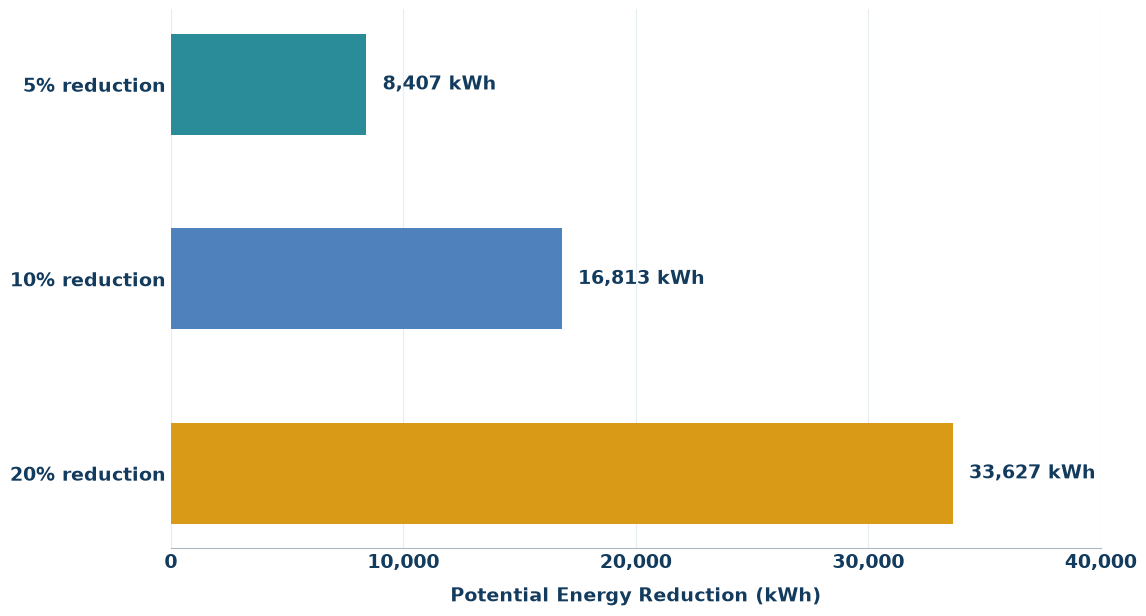

In [45]:

# Verified energy during successfully warned matched episodes
matched_energy_kwh = 168_134.25
matched_episodes = 4_218

# Illustrative reduction assumptions
reduction_rates = np.array([0.05, 0.10, 0.20])

# Calculate potential energy reduction
potential_savings = matched_energy_kwh * reduction_rates

labels = ["5%", "10%", "20%"]


# =========================================================
# PRESENTATION COLORS
# =========================================================

navy = "#123B5D"
teal = "#2B8C99"
gold = "#D99A18"
light_grey = "#E7EEF2"
axis_grey = "#AAB8C2"
blue = "#4F81BD"

colors = [teal, blue, gold]


# =========================================================
# PLOT
# =========================================================

fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_alpha(0)
ax.set_facecolor("white")


y = np.arange(len(labels))

bars = ax.barh(
    y,
    potential_savings,
    color=colors,
    height=0.52
)


# =========================================================
# VALUE LABELS
# =========================================================

for bar, value in zip(bars, potential_savings):

    ax.text(
        value + 700,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f} kWh",
        va="center",
        ha="left",
        fontsize=14,
        fontweight="bold",
        color=navy
    )


# =========================================================
# AXES
# =========================================================

ax.set_yticks(y)

ax.set_yticklabels(
    [f"{label} reduction" for label in labels],
    fontsize=14,
    fontweight="bold",
    color=navy
)

ax.invert_yaxis()


ax.set_xlabel(
    "Potential Energy Reduction (kWh)",
    fontsize=14,
    fontweight="bold",
    color=navy,
    labelpad=10
)


ax.set_xlim(0, 40_000)

ax.set_xticks(
    [0, 10_000, 20_000, 30_000, 40_000]
)

ax.set_xticklabels(
    ["0", "10,000", "20,000", "30,000", "40,000"],
    fontsize=14,
    fontweight="bold",
    color=navy
)


# =========================================================
# GRID + CLEAN STYLE
# =========================================================

ax.grid(
    axis="x",
    color=light_grey,
    linewidth=0.9
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color(axis_grey)

ax.tick_params(
    axis="y",
    length=0
)

ax.tick_params(
    axis="x",
    length=0
)



# =========================================================
# SAVE FOR POWERPOINT
# =========================================================

plt.savefig(
    "../presentation/potential_energy_reduction.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()